## **Rainfall Data Analysis**

## **Data Import & Setup**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
rainfall_df=pd.read_csv("https://github.com/kavithajuly1994-bit/Daily-Rainfall-data/raw/refs/heads/main/daily-rainfall-at-state-level.csv")
rainfall_df

,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0
...,...,...,...,...,...,...,...,...
204871,204871,2024-07-27,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.40,NaN
204872,204872,2024-07-28,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,8.30,NaN
204873,204873,2024-07-29,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,5.40,NaN
204874,204874,2024-07-30,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.30,NaN


* actual	Actual rainfall received on that day/state
* normal	Average/expected rainfall for that period based on historical data
* deviation	Difference between actual rainfall and normal rainfall (usually in %)
* rfs	Rainfall Frequency Score / Rainfall value in stand*ardized format (depends on dataset source)

In [3]:
rainfall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  object 
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  object 
 4   actual      187714 non-null  float64
 5   rfs         199011 non-null  float64
 6   normal      193358 non-null  float64
 7   deviation   173855 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 12.5+ MB


## **Data Formatting**

In [4]:

# Convert date columns to datetime

rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])

In [5]:
rainfall_df['month']=rainfall_df['date'].dt.month
rainfall_df

,id,date,state_code,state_name,actual,rfs,normal,deviation,month
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0,1
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0,1
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0,1
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0,1
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0,1
...,...,...,...,...,...,...,...,...,...
204871,204871,2024-07-27,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.40,NaN,7
204872,204872,2024-07-28,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,8.30,NaN,7
204873,204873,2024-07-29,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,5.40,NaN,7
204874,204874,2024-07-30,38,The Dadra And Nagar Haveli And Daman And Diu,NaN,0.000000,7.30,NaN,7


In [11]:
# Add Columns
rainfall_df['Rainfall_Category'] = 'Moderate'

In [12]:
rainfall_df['Rainfall_Category'] = 'Low'

rainfall_df.loc[rainfall_df['actual'] > 50,
                'Rainfall_Category'] = 'Moderate'

rainfall_df.loc[rainfall_df['actual'] > 100,
                'Rainfall_Category'] = 'Heavy'

In [13]:
print(rainfall_df[["actual", "Rainfall_Category"]].head(100))

    actual Rainfall_Category
0     0.00               Low
1     0.00               Low
2     0.00               Low
3     0.00               Low
4     0.00               Low
..     ...               ...
95    0.00               Low
96    0.00               Low
97    0.02               Low
98    0.00               Low
99    0.00               Low

[100 rows x 2 columns]


In [14]:
rainfall_df.loc[rainfall_df["actual"] > 100, "Rainfall_Category"] = "Heavy"

In [15]:
print(rainfall_df[rainfall_df["actual"] > 100][["actual", "Rainfall_Category"]].head())

      actual Rainfall_Category
5510  181.38             Heavy
6341  111.01             Heavy
6385  108.87             Heavy
6455  130.83             Heavy
6630  122.40             Heavy


In [16]:
print(rainfall_df["Rainfall_Category"].value_counts())

Rainfall_Category
Low         203541
Moderate      1133
Heavy          202
Name: count, dtype: int64


## **Data Cleaning**

In [6]:
rainfall_df.isna().sum()

,0
id,0
date,0
state_code,0
state_name,0
actual,17162
rfs,5865
normal,11518
deviation,31021
month,0


In [7]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
rainfall_df.describe()

,id,date,state_code,actual,rfs,normal,deviation,month
count,204876.000000,204876,204876.000000,187714.000000,199011.000000,193358.000000,173855.000000,204876.000000
mean,102437.500000,2016-10-16 00:00:00.000000256,19.166667,3.990693,9.643683,4.654058,38.516222,6.429450
min,0.000000,2009-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,-100.000000,1.000000
25%,51218.750000,2012-11-23 00:00:00,9.750000,0.000000,0.000000,0.420000,-100.000000,3.000000
50%,102437.500000,2016-10-16 00:00:00,18.500000,0.150000,0.063856,1.870000,-89.060000,6.000000
75%,153656.250000,2020-09-08 00:00:00,29.250000,3.890000,5.685068,6.760000,-9.045000,9.000000
max,204875.000000,2024-07-31 00:00:00,38.000000,283.000000,658.765073,97.680000,362300.000000,12.000000
std,59142.751213,NaN,11.171668,9.512507,27.504865,7.369770,1367.744520,3.438818


In [8]:
rainfall_df.describe(include="all")

,id,date,state_code,state_name,actual,rfs,normal,deviation,month
count,204876.000000,204876,204876.000000,204876,187714.000000,199011.000000,193358.000000,173855.000000,204876.000000
unique,NaN,NaN,NaN,36,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Uttarakhand,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,5691,NaN,NaN,NaN,NaN,NaN
mean,102437.500000,2016-10-16 00:00:00.000000256,19.166667,NaN,3.990693,9.643683,4.654058,38.516222,6.429450
min,0.000000,2009-01-01 00:00:00,1.000000,NaN,0.000000,0.000000,0.000000,-100.000000,1.000000
25%,51218.750000,2012-11-23 00:00:00,9.750000,NaN,0.000000,0.000000,0.420000,-100.000000,3.000000
50%,102437.500000,2016-10-16 00:00:00,18.500000,NaN,0.150000,0.063856,1.870000,-89.060000,6.000000
75%,153656.250000,2020-09-08 00:00:00,29.250000,NaN,3.890000,5.685068,6.760000,-9.045000,9.000000
max,204875.000000,2024-07-31 00:00:00,38.000000,NaN,283.000000,658.765073,97.680000,362300.000000,12.000000


In [19]:
num_cols = rainfall_df.select_dtypes(include=['float64', 'int64']).columns
num_cols

Index(['id', 'state_code', 'actual', 'rfs', 'normal', 'deviation'], dtype='object')

In [21]:
  rainfall_df["actual"].fillna(rainfall_df["actual"].median(),inplace=True)

In [22]:
rainfall_df["rfs"].fillna(rainfall_df["rfs"].median(),inplace=True)

In [23]:
rainfall_df["normal"].fillna(rainfall_df["normal"].mean(),inplace=True)

In [24]:
rainfall_df["deviation"].fillna(rainfall_df["deviation"].mean(),inplace=True)

Missing values in numerical columns such as actual, rfs, normal, and deviation were treated using median and mean imputation due to the presence of outliers.

In [25]:
rainfall_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204876 entries, Uttarakhand to The Dadra And Nagar Haveli And Daman And Diu
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 204876 non-null  int64         
 1   date               204876 non-null  datetime64[ns]
 2   state_code         204876 non-null  int64         
 3   actual             204876 non-null  float64       
 4   rfs                204876 non-null  float64       
 5   normal             204876 non-null  float64       
 6   deviation          204876 non-null  float64       
 7   month              204876 non-null  int32         
 8   Rainfall_Category  204876 non-null  object        
dtypes: datetime64[ns](1), float64(4), int32(1), int64(2), object(1)
memory usage: 14.8+ MB


In [26]:
# Duplicate Handling- Identify & remove duplicates
rainfall_df.duplicated().sum()

np.int64(0)

In [27]:
rainfall_df.drop_duplicates(inplace=True)

In [28]:
rainfall_df['Rainfall_Category'] = rainfall_df['Rainfall_Category'].astype('category')

Duplicate records were identified using duplicated() and removed using drop_duplicates() to improve data quality and avoid repeated observations.

## **Data Exploration using Pandas**

In [29]:
rainfall_df.head()

,id,date,state_code,actual,rfs,normal,deviation,month,Rainfall_Category
state_name,,,,,,,,,
Uttarakhand,0,2009-01-01,5,0.0,0.003906,2.19,-100.0,1,Low
Assam,1,2009-01-01,18,0.0,0.000000,0.52,-100.0,1,Low
Tripura,2,2009-01-01,16,0.0,0.000000,0.09,-100.0,1,Low
Telangana,3,2009-01-01,36,0.0,0.000000,0.17,-100.0,1,Low
Himachal Pradesh,4,2009-01-01,2,0.0,0.008566,3.31,-100.0,1,Low


In [30]:
rainfall_df.tail()

,id,date,state_code,actual,rfs,normal,deviation,month,Rainfall_Category
state_name,,,,,,,,,
The Dadra And Nagar Haveli And Daman And Diu,204871,2024-07-27,38,0.15,0.0,7.4,38.516222,7,Low
The Dadra And Nagar Haveli And Daman And Diu,204872,2024-07-28,38,0.15,0.0,8.3,38.516222,7,Low
The Dadra And Nagar Haveli And Daman And Diu,204873,2024-07-29,38,0.15,0.0,5.4,38.516222,7,Low
The Dadra And Nagar Haveli And Daman And Diu,204874,2024-07-30,38,0.15,0.0,7.3,38.516222,7,Low
The Dadra And Nagar Haveli And Daman And Diu,204875,2024-07-31,38,0.15,0.0,4.2,38.516222,7,Low


In [31]:
rainfall_df.shape

(204876, 9)

In [32]:
rainfall_df.columns

Index(['id', 'date', 'state_code', 'actual', 'rfs', 'normal', 'deviation',
       'month', 'Rainfall_Category'],
      dtype='object')

In [33]:
rainfall_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204876 entries, Uttarakhand to The Dadra And Nagar Haveli And Daman And Diu
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 204876 non-null  int64         
 1   date               204876 non-null  datetime64[ns]
 2   state_code         204876 non-null  int64         
 3   actual             204876 non-null  float64       
 4   rfs                204876 non-null  float64       
 5   normal             204876 non-null  float64       
 6   deviation          204876 non-null  float64       
 7   month              204876 non-null  int32         
 8   Rainfall_Category  204876 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(4), int32(1), int64(2)
memory usage: 21.5+ MB


In [34]:
rainfall_df.dtypes


,0
id,int64
date,datetime64[ns]
state_code,int64
actual,float64
rfs,float64
normal,float64
deviation,float64
month,int32
Rainfall_Category,category


In [35]:
rainfall_df.describe(include="all")

,id,date,state_code,actual,rfs,normal,deviation,month,Rainfall_Category
count,204876.000000,204876,204876.000000,204876.000000,204876.000000,204876.000000,204876.000000,204876.000000,204876
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203541
mean,102437.500000,2016-10-16 00:00:00.000000256,19.166667,3.668967,9.369440,4.654058,38.516222,6.429450,NaN
min,0.000000,2009-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,-100.000000,1.000000,NaN
25%,51218.750000,2012-11-23 00:00:00,9.750000,0.000000,0.000000,0.460000,-100.000000,3.000000,NaN
50%,102437.500000,2016-10-16 00:00:00,18.500000,0.150000,0.063856,2.250000,-69.960000,6.000000,NaN
75%,153656.250000,2020-09-08 00:00:00,29.250000,3.220000,5.275318,6.370000,38.516222,9.000000,NaN
max,204875.000000,2024-07-31 00:00:00,38.000000,283.000000,658.765073,97.680000,362300.000000,12.000000,NaN


In [36]:
rainfall_df.isna().sum()

,0
id,0
date,0
state_code,0
actual,0
rfs,0
normal,0
deviation,0
month,0
Rainfall_Category,0


## **Statistical Analysis**

In [37]:
stats_cols = ['actual',
              'rfs',
              'normal',
              'deviation',
]

In [39]:
summary_stats = pd.DataFrame({
    'Mean': rainfall_df[stats_cols].mean(),
    'Median': rainfall_df[stats_cols].median(),
    'Mode': rainfall_df[stats_cols].mode().iloc[0],
    'Std Dev': rainfall_df[stats_cols].std(),
    'Variance': rainfall_df[stats_cols].var(),
    '25%': rainfall_df[stats_cols].quantile(0.25),
    '50%': rainfall_df[stats_cols].quantile(0.50),
    '75%': rainfall_df[stats_cols].quantile(0.75)
})

summary_stats

,Mean,Median,Mode,Std Dev,Variance,25%,50%,75%
actual,3.668967,0.150000,0.000000,9.167330,8.403994e+01,0.00,0.150000,3.220000
rfs,9.369440,0.063856,0.000000,27.155342,7.374126e+02,0.00,0.063856,5.275318
normal,4.654058,2.250000,4.654058,7.159610,5.126002e+01,0.46,2.250000,6.370000
deviation,38.516222,-69.960000,-100.000000,1259.948645,1.587471e+06,-100.00,-69.960000,38.516222


Descriptive statistical analysis was performed on related numerical variables including actual, rfs, normal, deviation. Measures such as mean, median, mode, standard deviation, variance, and percentiles were calculated to understand  distribution, variability, and central tendency.

In [40]:

num_cols = [
    'actual',
    'rfs',
    'normal',
    'deviation',
]

## **Box Plot Outliers**

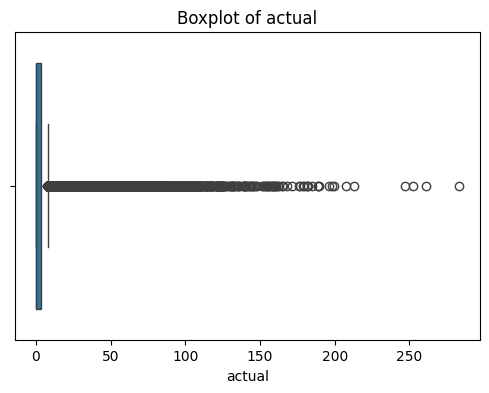

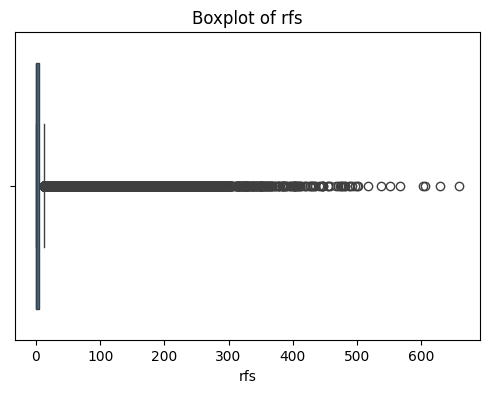

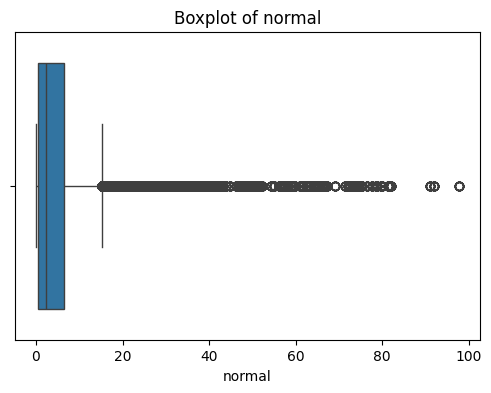

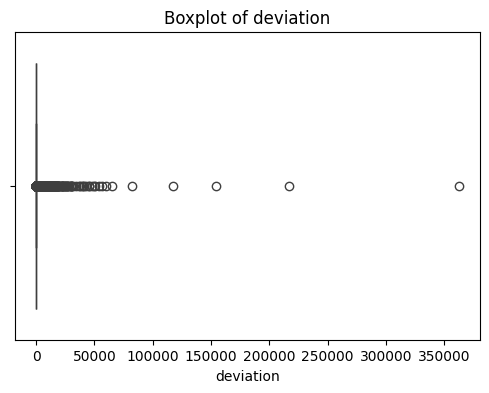

In [41]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=rainfall_df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

In [43]:
rainfall_df[num_cols].skew()

,0
actual,6.315522
rfs,6.257955
normal,4.739375
deviation,161.560884


In [44]:
rainfall_df[num_cols].kurtosis()

,0
actual,71.247741
rfs,59.675509
normal,35.543820
deviation,39392.615503


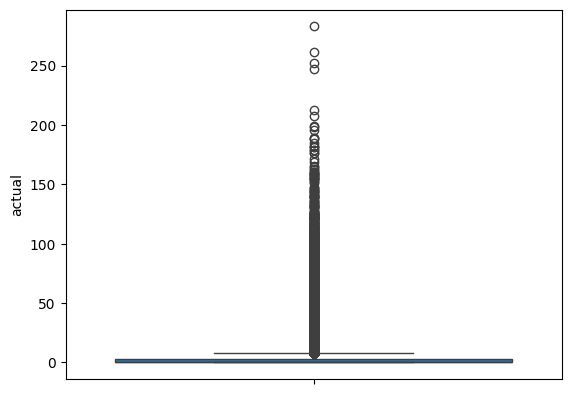

In [46]:
sns.boxplot(rainfall_df['actual'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

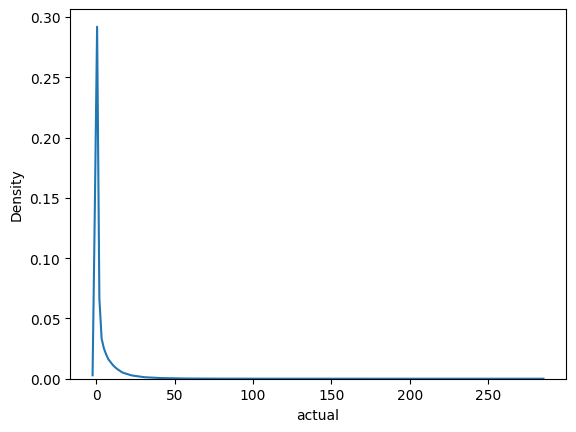

In [47]:
sns.kdeplot(rainfall_df["actual"])
plt.show

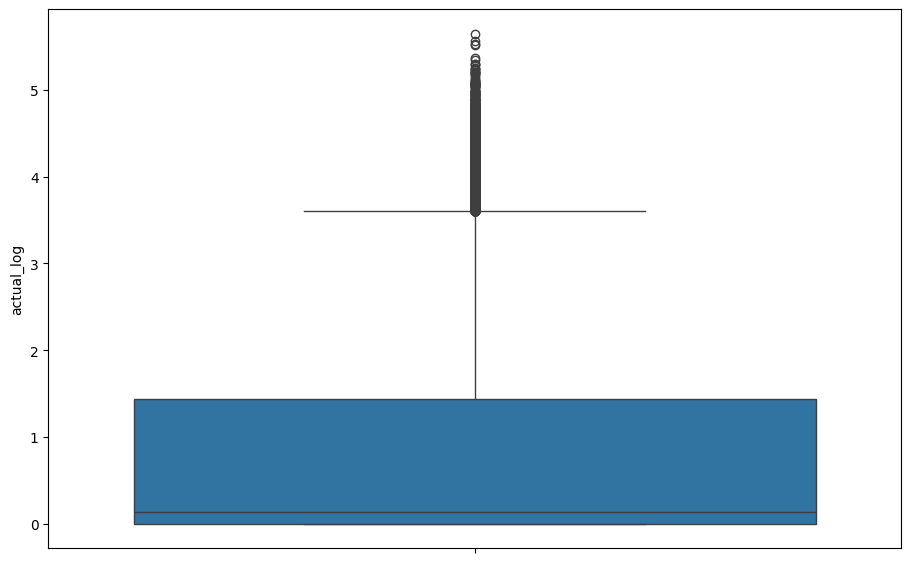

In [48]:
import numpy as np
rainfall_df['actual_log'] = np.log1p(rainfall_df['actual'])

plt.figure(figsize=(11,7))
sns.boxplot(data=rainfall_df['actual_log'])
plt.show()

In [49]:
print("Original Skewness :", rainfall_df['actual'].skew())

Original Skewness : 6.315522471902587


In [50]:
rainfall_df['actual_log'].skew()

np.float64(1.2642962657869667)

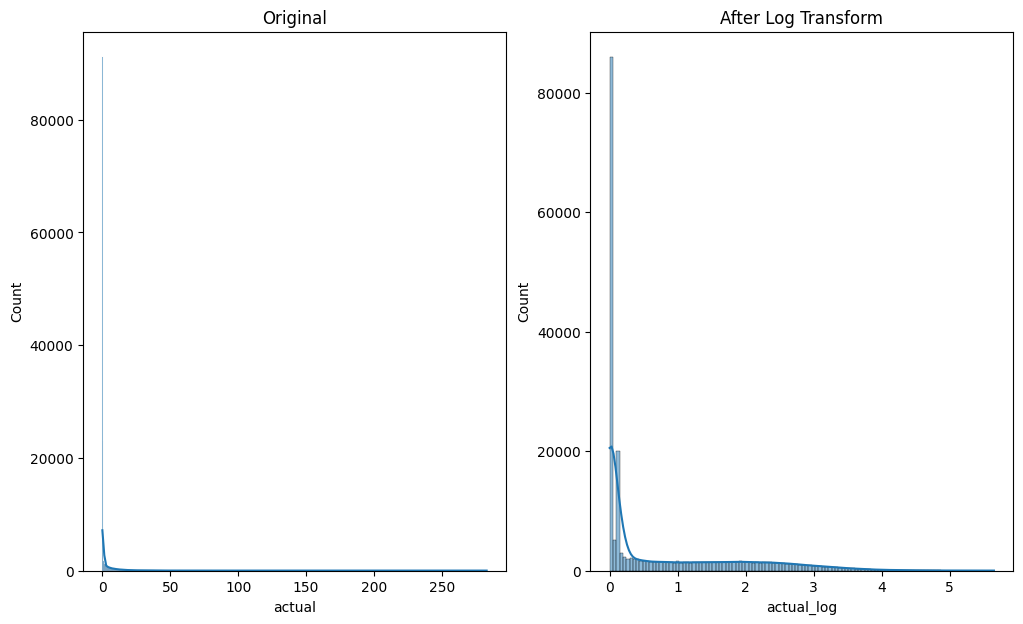

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12,7))

sns.histplot(rainfall_df['actual'], kde=True, ax=ax[0])
ax[0].set_title("Original")

sns.histplot(rainfall_df['actual_log'], kde=True, ax=ax[1])
ax[1].set_title("After Log Transform")

plt.show()

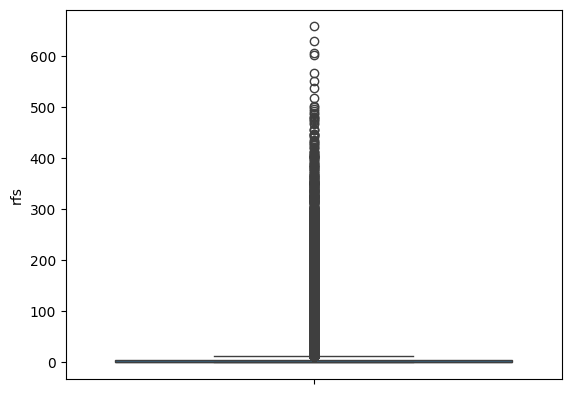

In [52]:
sns.boxplot(rainfall_df['rfs'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

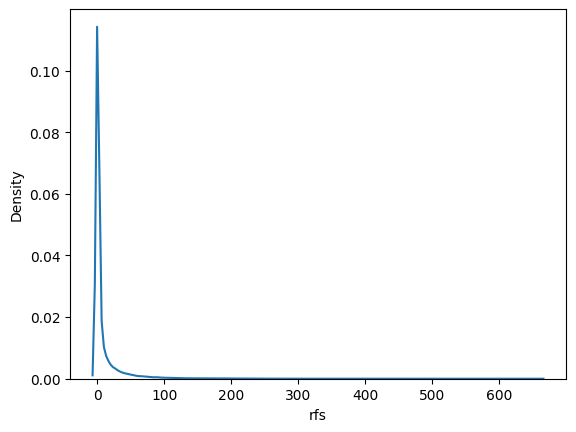

In [53]:
sns.kdeplot(rainfall_df["rfs"])
plt.show

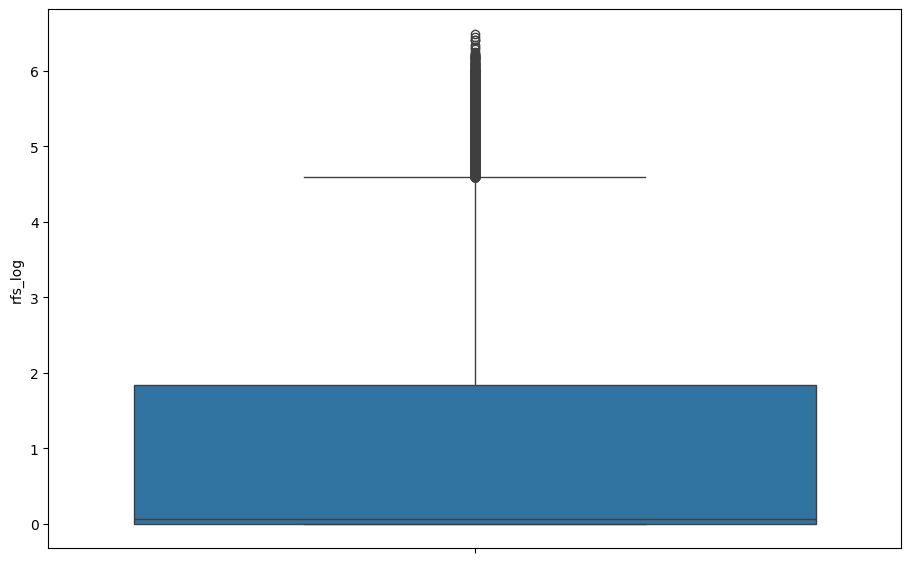

In [54]:
rainfall_df['rfs_log'] = np.log1p(rainfall_df['rfs'])

plt.figure(figsize=(11,7))
sns.boxplot(data=rainfall_df['rfs_log'])
plt.show()

In [55]:
print("Original Skewness :", rainfall_df['rfs'].skew())

Original Skewness : 6.2579553787069955


In [56]:
rainfall_df['rfs_log'].skew()

np.float64(1.260758659886076)

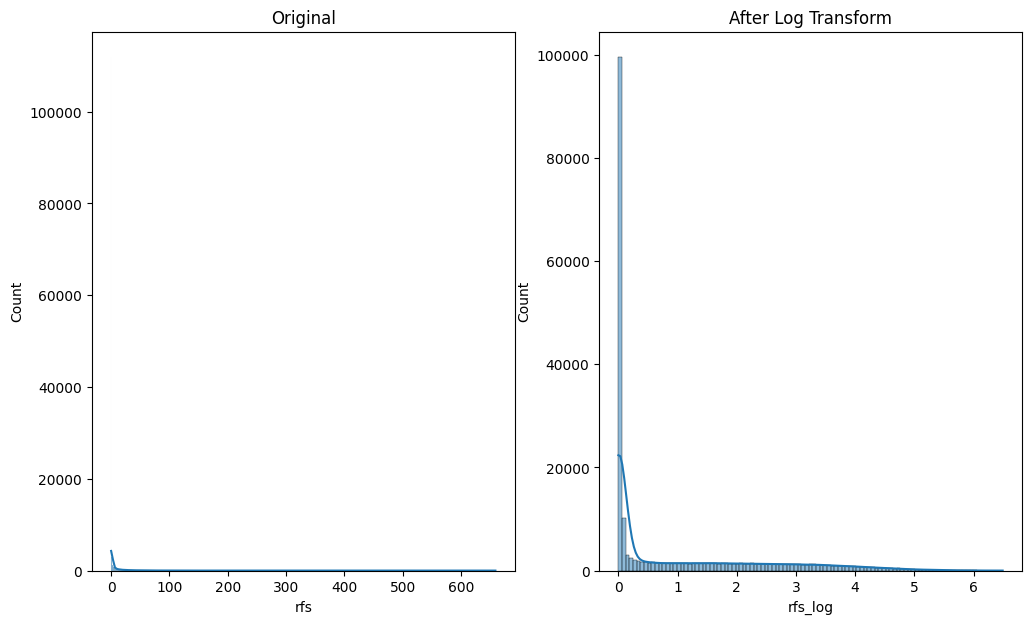

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12,7))

sns.histplot(rainfall_df['rfs'], kde=True, ax=ax[0])
ax[0].set_title("Original")

sns.histplot(rainfall_df['rfs_log'], kde=True, ax=ax[1])
ax[1].set_title("After Log Transform")

plt.show()

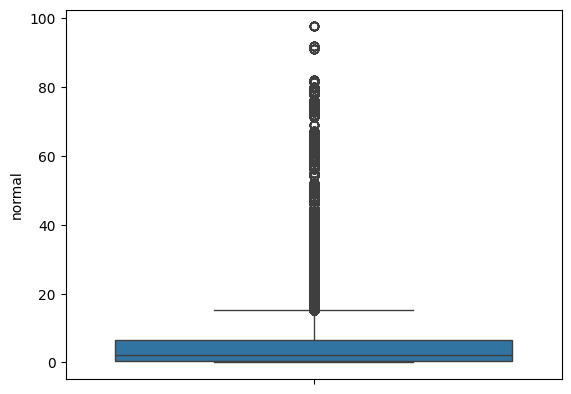

In [58]:
sns.boxplot(rainfall_df['normal'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

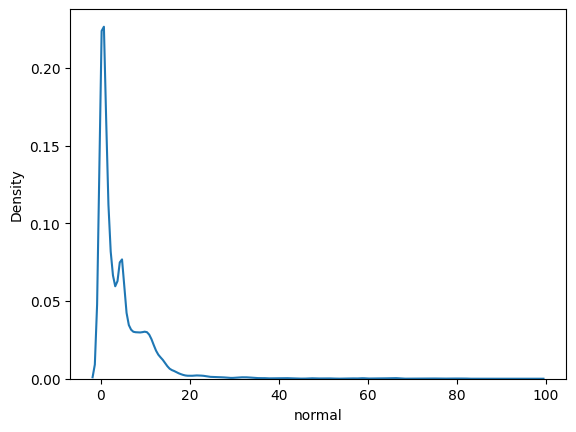

In [59]:
sns.kdeplot(rainfall_df["normal"])
plt.show

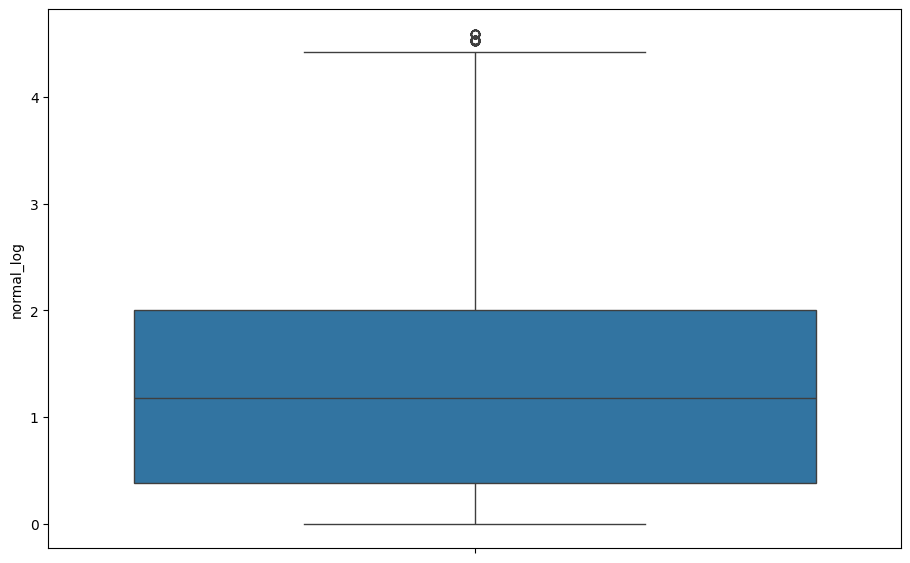

In [60]:
rainfall_df['normal_log'] = np.log1p(rainfall_df['normal'])

plt.figure(figsize=(11,7))
sns.boxplot(data=rainfall_df['normal_log'])
plt.show()

In [61]:
print("Original Skewness :", rainfall_df['normal'].skew())

Original Skewness : 4.739374813023805


In [62]:
rainfall_df['normal_log'].skew()

np.float64(0.4150353675413912)

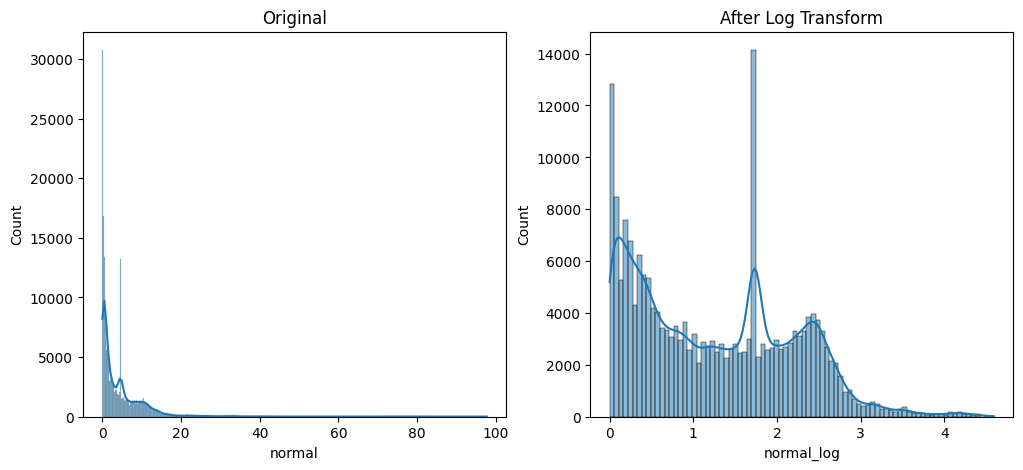

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(rainfall_df['normal'], kde=True, ax=ax[0])
ax[0].set_title("Original")

sns.histplot(rainfall_df['normal_log'], kde=True, ax=ax[1])
ax[1].set_title("After Log Transform")

plt.show()

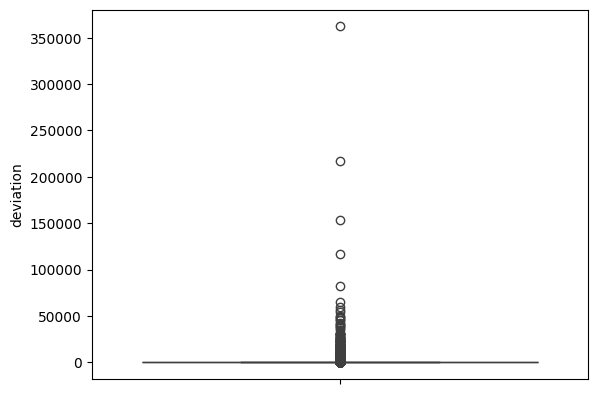

In [64]:
sns.boxplot(y=rainfall_df['deviation'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

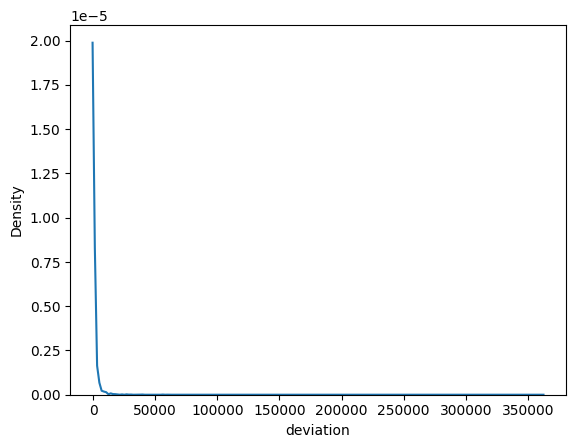

In [65]:
sns.kdeplot(rainfall_df["deviation"])
plt.show

In [66]:
Q1 = rainfall_df['deviation'].quantile(0.25)
Q3 = rainfall_df['deviation'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rainfall_df['deviation_capped'] = rainfall_df['deviation'].clip(lower, upper)

In [67]:
print("Original Skewness :", rainfall_df['deviation'].skew())

Original Skewness : 161.56088435828937


In [68]:
rainfall_df['deviation_capped'].skew()

np.float64(1.3697203023284892)

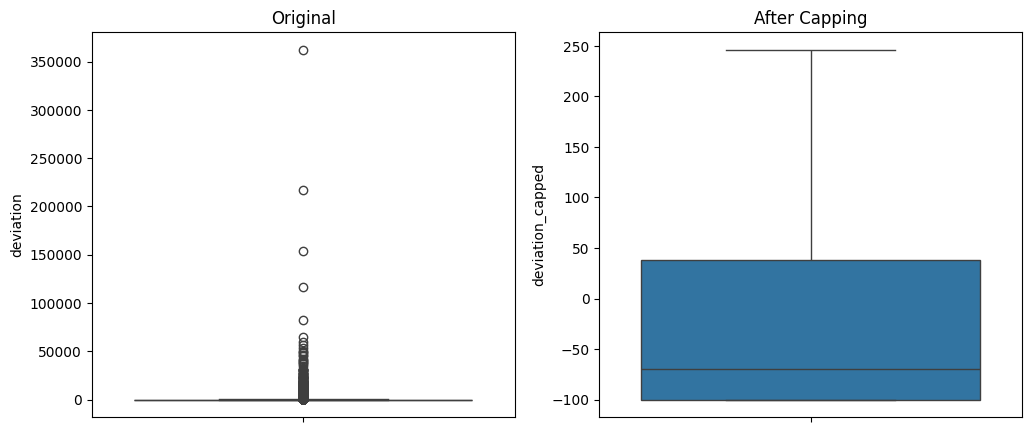

In [69]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(y=rainfall_df['deviation'], ax=ax[0])
ax[0].set_title("Original")

sns.boxplot(y=rainfall_df['deviation_capped'], ax=ax[1])
ax[1].set_title("After Capping")

plt.show()

## **Data Visualization**

## **Line Plot**

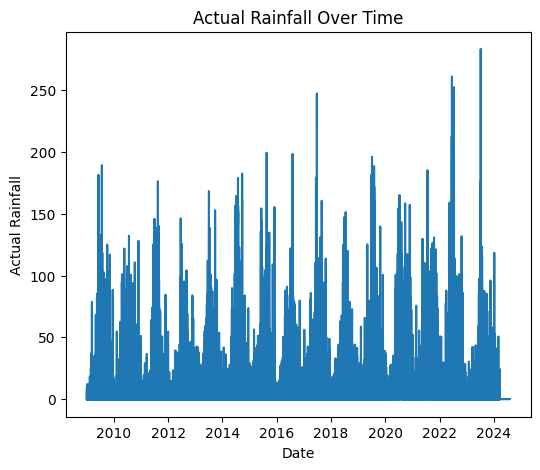

In [70]:
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])

plt.figure(figsize=(6,5))
plt.plot(rainfall_df['date'],
         rainfall_df['actual'])
plt.title("Actual Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Actual Rainfall")
plt.show()

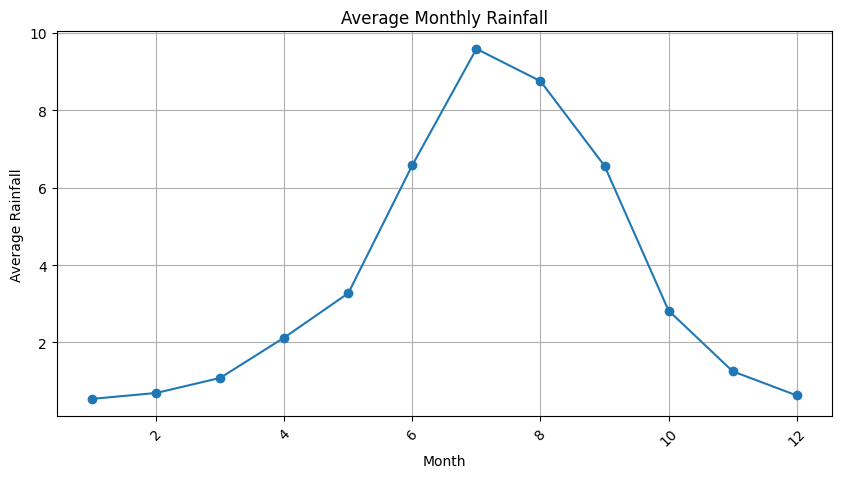

In [71]:
monthly_rainfall = rainfall_df.groupby('month')['actual'].mean()

plt.figure(figsize=(10,5))

plt.plot(monthly_rainfall.index,
         monthly_rainfall.values,
         marker='o')

plt.title("Average Monthly Rainfall")

plt.xlabel("Month")
plt.ylabel("Average Rainfall")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

**Insight**

* Rainfall varies significantly across months.
* July months show higher rainfall peaks indicating seasonal rainfall patterns.

## **Histogram **

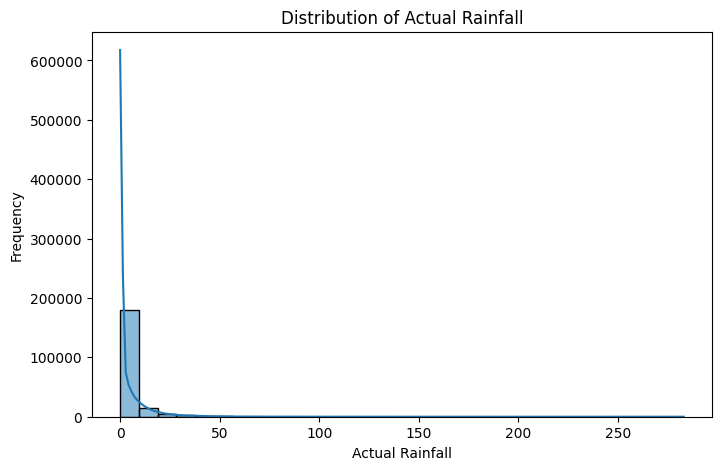

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(rainfall_df['actual'],
         bins=30,kde=True)

plt.title("Distribution of Actual Rainfall")

plt.xlabel("Actual Rainfall")
plt.ylabel("Frequency")

plt.show()

**Insight**

* Distribution became more balanced after transformation.
* Skewness reduced significantly.
* Extreme rainfall values became compressed.

# **Box Plot**

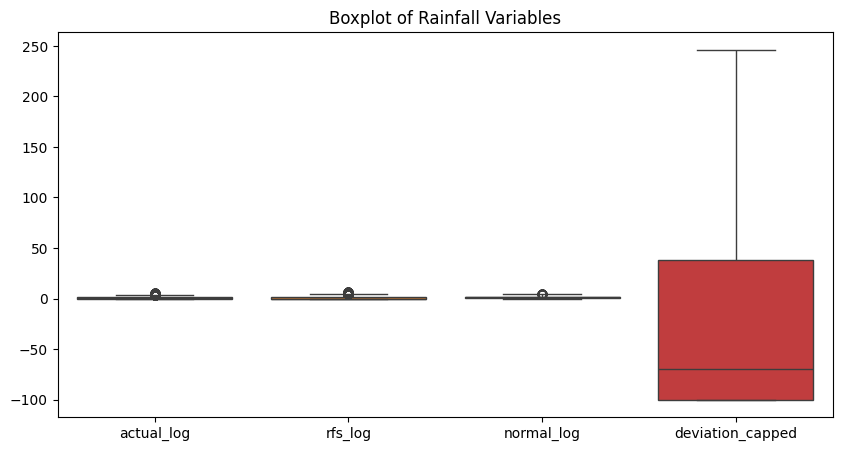

In [73]:
cols = ['actual_log', 'rfs_log', 'normal_log', 'deviation_capped']

plt.figure(figsize=(10,5))

sns.boxplot(data=rainfall_df[cols])

plt.title("Boxplot of Rainfall Variables")

plt.show()

**Insighs**

* Extreme outliers were significantly reduced.
* Distribution became more stable.
* Data variability improved without deleting records.

## **Heat Map - Correlation Analysis**

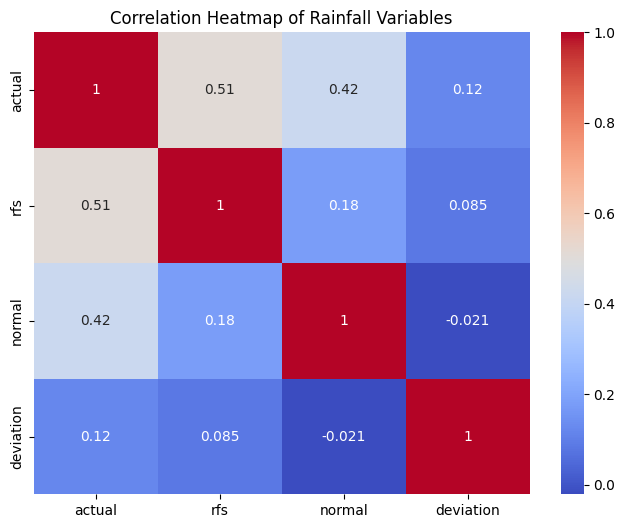

In [75]:
corr = rainfall_df[['actual',
                    'rfs',
                    'normal',
                    'deviation']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap of Rainfall Variables")

plt.show()

**Insight**

* Strong positive relationship observed between rainfall variables.
Regions or periods with higher normal rainfall tend to receive higher actual rainfall.
* Actual rainfall positively correlated with rfs and normal rainfall.
Since deviation can contain both positive and negative values, its relationship with other variables is less stable.
* Correlation analysis helped identify variable dependency.

## **Scatter Plot**

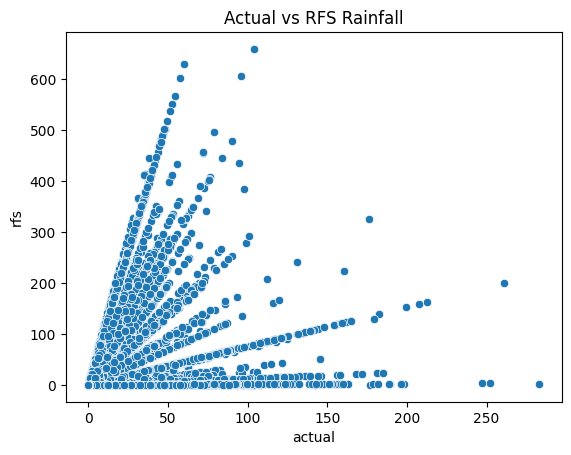

In [76]:
sns.scatterplot(x='actual', y='rfs', data=rainfall_df)
plt.title("Actual vs RFS Rainfall")

plt.show()

**Insight**

* Positive relationship observed between actual rainfall and rfs values.
* Higher actual rainfall generally corresponded with higher forecast values.
* Some scattered points indicate rainfall variability.

# **Count Plot **

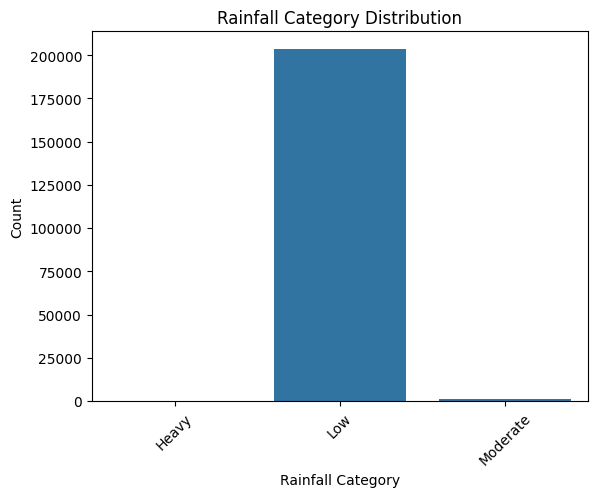

In [77]:
sns.countplot(x='Rainfall_Category',
              data=rainfall_df)

plt.title("Rainfall Category Distribution")

plt.xlabel("Rainfall Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

**Insight**

* Moderate rainfall categories appeared more frequently.
* Heavy rainfall events occurred less frequently.
* The chart clearly showed rainfall intensity distribution.

## **Bar Chart**

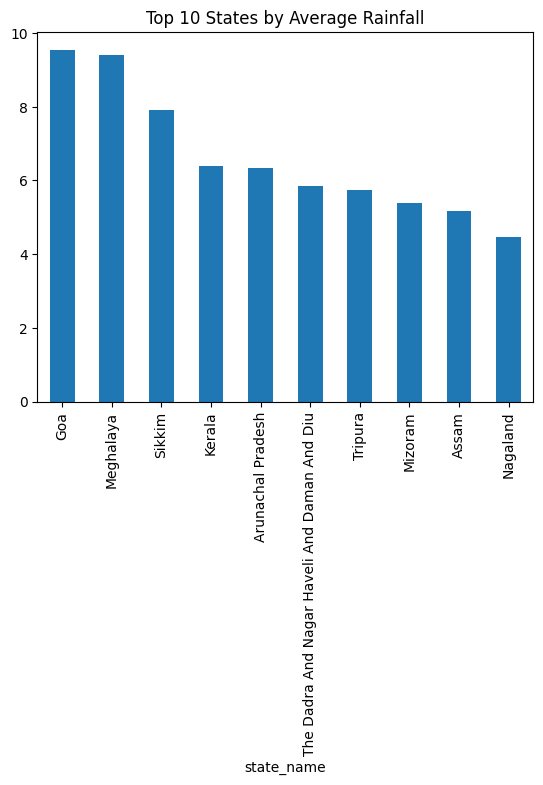

In [78]:
top_states = rainfall_df.groupby('state_name')['actual'].mean().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')

plt.title("Top 10 States by Average Rainfall")

plt.show()

**Insights**

* Top 10 states receive considerably higher rainfall compared to others.
* The chart highlights regional rainfall differences.
* High rainfall states Goa has stronger monsoon influence, while Ngaland receives the lowest rainfall.


## **Pie Chart**

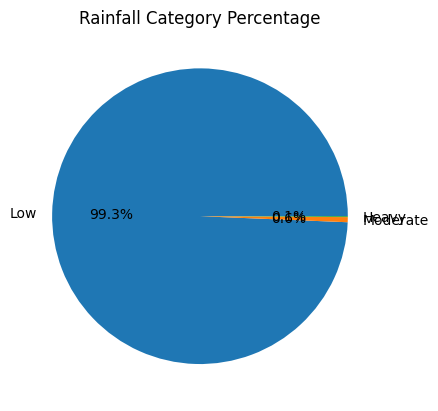

In [80]:
category_counts = rainfall_df['Rainfall_Category'].value_counts()

plt.pie(category_counts,
        labels=category_counts.index,
        autopct='%1.1f%%')

plt.title("Rainfall Category Percentage")

plt.show()

**Insight**

* The pie chart shows that low rainfall conditions dominate the dataset, contributing approximately 99.3% of total observations.
* Moderate rainfall accounts for only 0.6%, while heavy rainfall contributes around 0.3%.
* This indicates that extreme rainfall events are very rare compared to normal rainfall conditions

## **Pair Plot**

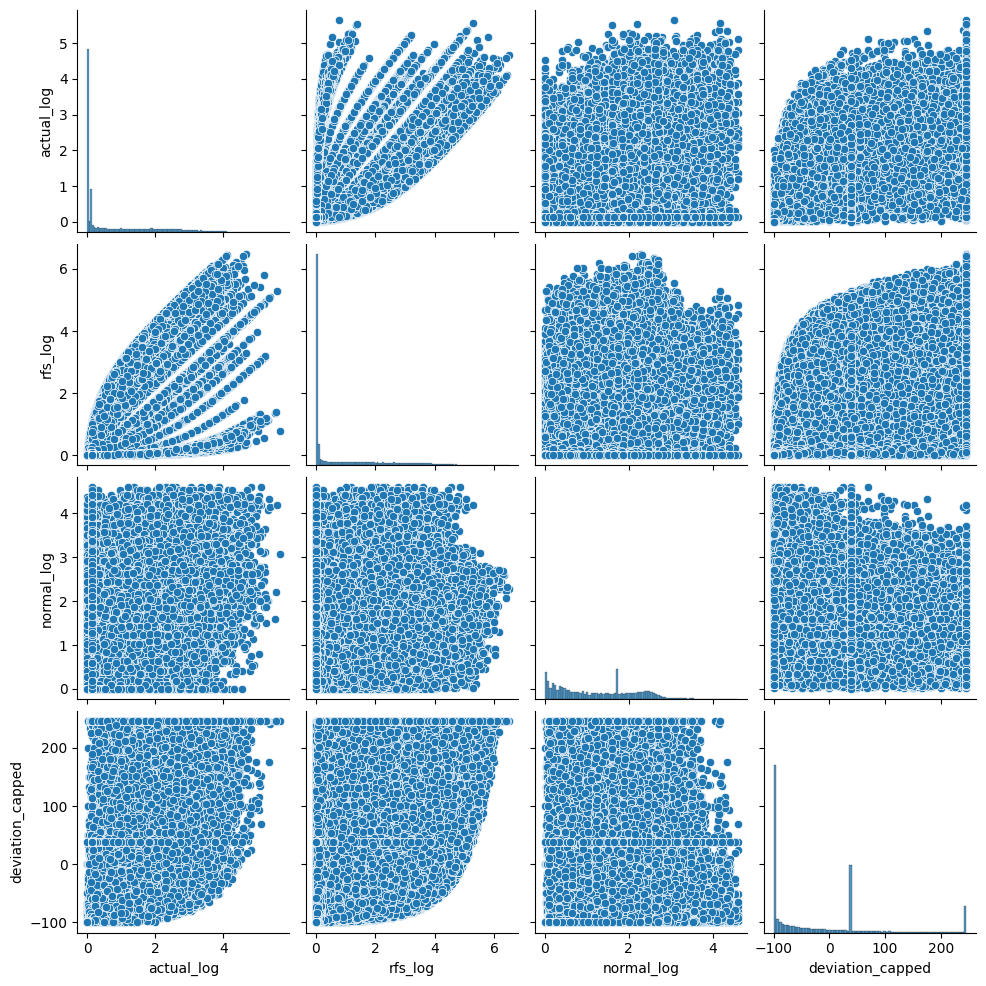

In [81]:
sns.pairplot(rainfall_df[['actual_log',
                          'rfs_log',
                          'normal_log',
                          'deviation_capped']])

**Insight**

* Pairwise relationships between numerical variables were visualized.
* Positive relationships and clustering patterns were observed.
* Outlier concentration was visible in some variables.

<Axes: xlabel='Rainfall_Category', ylabel='actual'>

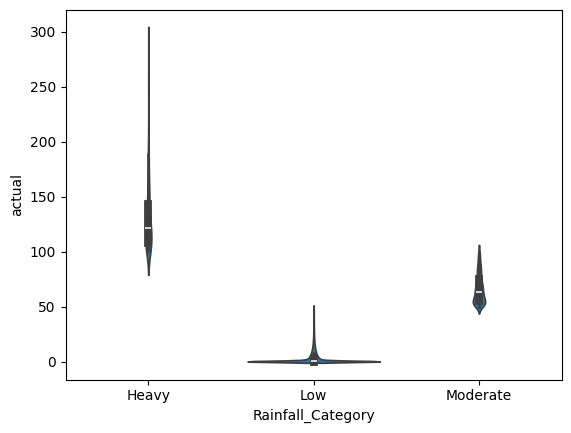

In [82]:
sns.violinplot(x='Rainfall_Category', y='actual', data=rainfall_df)

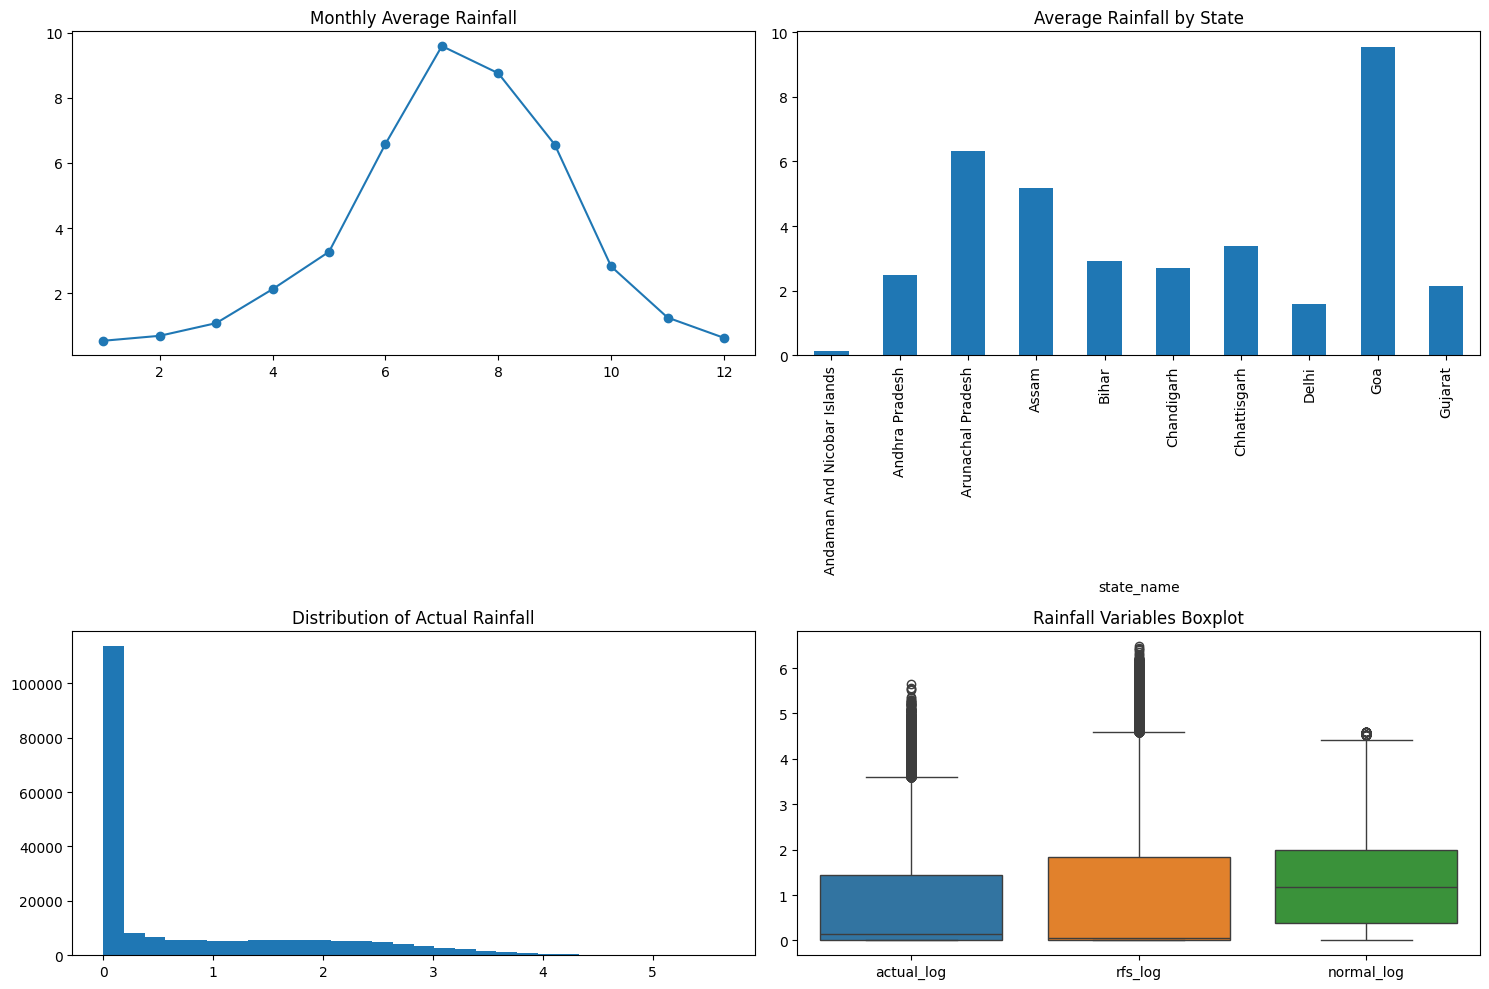

In [83]:
fig, ax = plt.subplots(2,2, figsize=(15,10))

# 1 Line Chart
monthly = rainfall_df.groupby('month')['actual'].mean()

ax[0,0].plot(monthly.index,
             monthly.values,
             marker='o')

ax[0,0].set_title("Monthly Average Rainfall")


# 2 Bar Chart
top_states = rainfall_df.groupby('state_name')['actual'].mean().head(10)

top_states.plot(kind='bar',
                ax=ax[0,1])

ax[0,1].set_title("Average Rainfall by State")


# 3 Histogram
ax[1,0].hist(rainfall_df['actual_log'],
             bins=30)

ax[1,0].set_title("Distribution of Actual Rainfall")


# 4 Box Plot
sns.boxplot(data=rainfall_df[['actual_log',
                              'rfs_log',
                              'normal_log']],
            ax=ax[1,1])

ax[1,1].set_title("Rainfall Variables Boxplot")


plt.tight_layout()

plt.show()

**Final Insights**

* Rainfall patterns varied significantly across months and states.
* Most rainfall variables were highly right-skewed with extreme outliers.
* Log transformation reduced skewness and improved data distribution.
* Deviation contained the highest outliers and was treated using IQR capping.
* Positive correlation existed between actual, rfs, and normal rainfall.
* Moderate rainfall events occurred more frequently than heavy rainfall events.* Preprocessing improved overall data quality and visualization clarity.